# 01 - Inicjalizacja i Labelowanie

Ten notebook pokrywa:
1. inicjalizacje srodowiska i sciezek,
2. demo generowania screenow,
3. podglad labelowania i tworzenie datasetu.

In [7]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()

import sys
if not (PROJECT_ROOT / 'src').exists():
    p = PROJECT_ROOT
    while True:
        if (p / 'src').exists():
            PROJECT_ROOT = p
            break
        if p == p.parent:
            break
        p = p.parent
sys.path.insert(0, str(PROJECT_ROOT))

TRAIN_DIR = PROJECT_ROOT / 'data' / 'segmentation' / 'train'
TEST_DIR = PROJECT_ROOT / 'data' / 'segmentation' / 'test'
REAL_SCREENSHOTS_DIR = PROJECT_ROOT / 'src' / 'dataset' / 'Real_screenshots'
OUT_DIR = PROJECT_ROOT / 'data' / 'real_screenshot_predictions'
OUT_DIR.mkdir(parents=True, exist_ok=True)

from src.dataset.pacman_map_dataset import PacmanMapDatasetGenerator, CLASS_TO_ID
from src.environment.game_logic import GameState

ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

print('PROJECT_ROOT:', PROJECT_ROOT)
print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR:', TEST_DIR)
print('Num classes:', len(CLASS_TO_ID))

PROJECT_ROOT: /home/mwrona/PAC-MAN-AI
TRAIN_DIR: /home/mwrona/PAC-MAN-AI/data/segmentation/train
TEST_DIR: /home/mwrona/PAC-MAN-AI/data/segmentation/test
Num classes: 14


In [2]:
import ipywidgets as widgets
from IPython.display import display

gen = PacmanMapDatasetGenerator()
seed_slider = widgets.IntSlider(description='Seed', min=0, max=2**31 - 1, value=0)
steps_slider = widgets.IntSlider(description='Rollout steps', min=0, max=200, value=50)
btn = widgets.Button(description='Render sample')
out = widgets.Output()

def render_sample(seed, steps):
    state = GameState(seed=int(seed))
    for _ in range(int(steps)):
        if state.is_terminal():
            break
        state.step(int(np.random.default_rng().integers(0, 4)))
    frame, annotation, mask = gen.render_state(state)
    return frame, mask, annotation

def on_click(_):
    with out:
        out.clear_output(wait=True)
        frame, mask, ann = render_sample(seed_slider.value, steps_slider.value)
        display(frame)
        display(mask)
        print('HUD:', ann.get('hud'))
        print('Instances:', len(ann.get('instances', [])))

btn.on_click(on_click)
display(widgets.VBox([seed_slider, steps_slider, btn, out]))

In [3]:
def _group_for_label(label: str) -> str:
    if label in {'blinky', 'pinky', 'inky', 'clyde', 'frightened_ghost', 'ghost_eyes'}:
        return 'ghosts'
    if label == 'fruit':
        return 'fruit'
    if label == 'pacman':
        return 'pacman'
    if label in {'pellet', 'power_pellet'}:
        return 'collectibles'
    return 'other'

GROUP_COLORS = {
    'pacman': '#ffd400',
    'ghosts': '#5ac8fa',
    'fruit': '#ff7a59',
    'collectibles': '#b8f397',
    'other': '#ffffff',
}

def show_annotated_image(image: np.ndarray, instances: list, playfield_bbox=None, figsize=(14, 12), show=True):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)
    if playfield_bbox is not None:
        x0, y0, bw, bh = playfield_bbox
        ax.add_patch(Rectangle((x0, y0), bw, bh, fill=False, edgecolor='#00e5ff', linewidth=3))
    for obj in instances:
        x, y, w, h = obj['bbox']
        label = obj['label']
        color = GROUP_COLORS.get(_group_for_label(label), '#ffffff')
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2))
        ax.text(x, max(0, y - 6), label, color=color, fontsize=9, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1, edgecolor='none'))
    ax.axis('off')
    if show:
        plt.show()
    return fig, ax

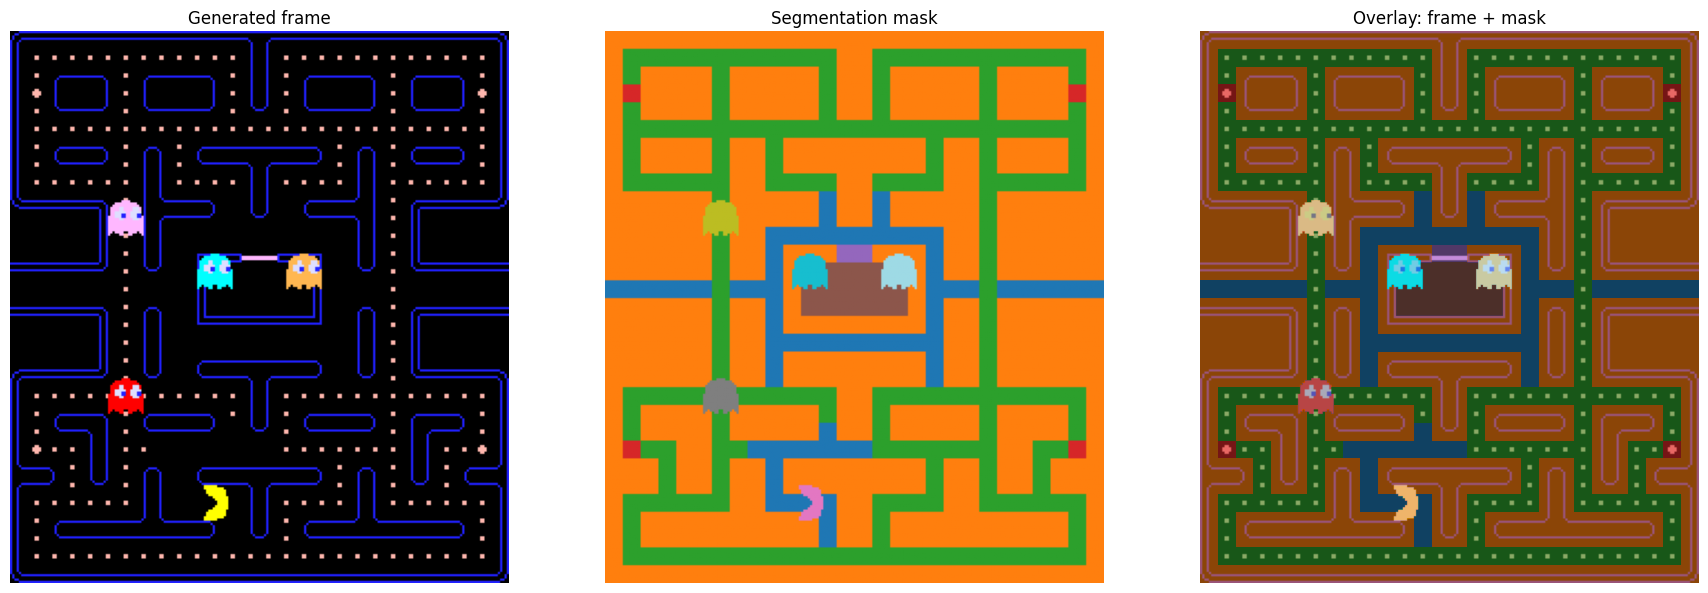

HUD: {'score': 140, 'lives': 3, 'level': 1, 'fruit_active': False}
Mask classes (non-background):
  id= 1  pixels= 34716  name=wall
  id= 2  pixels= 14170  name=pellet
  id= 5  pixels=   890  name=ghost_house
  id= 3  pixels=   256  name=power_pellet
  id= 7  pixels=   212  name=blinky
  id= 8  pixels=   212  name=pinky
  id= 9  pixels=   212  name=inky
  id=10  pixels=   212  name=clyde
  id= 4  pixels=   128  name=ghost_door
  id= 6  pixels=   118  name=pacman


In [ ]:
# Wizualizacja 1: pojedyncza próbka (frame + mask + overlay)
seed = 123
steps = 80

frame, mask, ann = render_sample(seed, steps)
mask_arr = np.asarray(mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(frame)
axes[0].set_title('Generated frame')
axes[0].axis('off')

axes[1].imshow(mask_arr, cmap='tab20')
axes[1].set_title('Segmentation mask')
axes[1].axis('off')

axes[2].imshow(frame)
overlay = np.ma.masked_where(mask_arr == 0, mask_arr)
axes[2].imshow(overlay, cmap='tab20', alpha=0.55, interpolation='nearest')
axes[2].set_title('Overlay: frame + mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

unique_ids, counts = np.unique(mask_arr, return_counts=True)
class_stats = [(int(cid), int(cnt), ID_TO_CLASS.get(int(cid), f'class_{int(cid)}')) for cid, cnt in zip(unique_ids, counts) if int(cid) != 0]
class_stats = sorted(class_stats, key=lambda x: x[1], reverse=True)

print('HUD:', ann.get('hud'))
print('Mask classes (non-background):')
for cid, cnt, name in class_stats[:12]:
    print(f'  id={cid:2d}  pixels={cnt:6d}  name={name}')
if not class_stats:
    print('  (no non-background pixels found)')

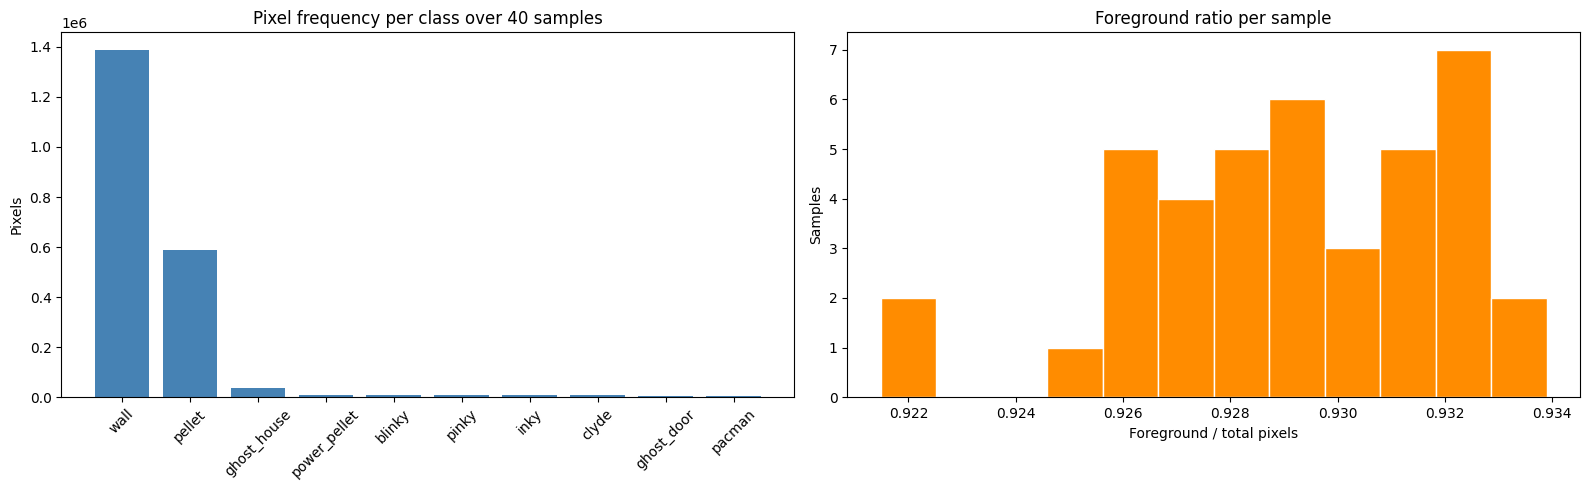

Mean foreground ratio: 0.9291
Std foreground ratio : 0.0028


In [10]:
# Wizualizacja 2: rozkład klas na wielu próbkach (na podstawie masek)
from collections import Counter

n_samples = 40
pixel_counter = Counter()
foreground_ratio = []

for i in range(n_samples):
    _, mask_i, _ = render_sample(seed=1000 + i, steps=40 + (i % 120))
    mask_arr = np.asarray(mask_i)
    h, w = mask_arr.shape
    total_px = h * w
    fg_px = int((mask_arr != 0).sum())
    foreground_ratio.append(fg_px / max(1, total_px))

    ids, cnts = np.unique(mask_arr, return_counts=True)
    for cid, cnt in zip(ids, cnts):
        cid = int(cid)
        if cid == 0:
            continue
        pixel_counter[cid] += int(cnt)

if pixel_counter:
    sorted_items = sorted(pixel_counter.items(), key=lambda x: x[1], reverse=True)
    labels = [ID_TO_CLASS.get(cid, f'class_{cid}') for cid, _ in sorted_items]
    values = [v for _, v in sorted_items]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(labels, values, color='steelblue')
    axes[0].set_title(f'Pixel frequency per class over {n_samples} samples')
    axes[0].set_ylabel('Pixels')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].hist(foreground_ratio, bins=12, color='darkorange', edgecolor='white')
    axes[1].set_title('Foreground ratio per sample')
    axes[1].set_xlabel('Foreground / total pixels')
    axes[1].set_ylabel('Samples')

    plt.tight_layout()
    plt.show()

    print('Mean foreground ratio:', round(float(np.mean(foreground_ratio)), 4))
    print('Std foreground ratio :', round(float(np.std(foreground_ratio)), 4))
else:
    print('No non-background classes found in sampled masks.')

In [4]:
if not (TRAIN_DIR / 'images').exists():
    print('Generating training dataset... (2000 samples)')
    gen = PacmanMapDatasetGenerator()
    gen.generate_dataset(TRAIN_DIR, sample_count=2000, seed=0, max_random_steps=200)
else:
    print('Train dataset already exists, skipping generation')

if not (TEST_DIR / 'images').exists():
    print('Generating test dataset... (500 samples)')
    gen = PacmanMapDatasetGenerator()
    gen.generate_dataset(TEST_DIR, sample_count=500, seed=1, max_random_steps=200)
else:
    print('Test dataset already exists, skipping generation')

Train dataset already exists, skipping generation
Test dataset already exists, skipping generation
